In [ ]:
import tensorflow as tf

# Check if TensorFlow is using GPU
gpu_device = tf.config.list_physical_devices('GPU')
if gpu_device:
    print("GPU is available.")
else:
    print("GPU is not available.")


GPU is available.


In [ ]:
import torch

# Check if CUDA (GPU) is available
if torch.cuda.is_available():
    print(f"CUDA is available. Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available.")


CUDA is available. Using GPU: Tesla T4


In [ ]:
!nvidia-smi

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [ ]:
#from sklearn import neighborssum
from sklearn import metrics
from sklearn import model_selection
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
%matplotlib inline

In [ ]:
#building the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# beneficiary data
bene_train = pd.read_csv('Train_Beneficiarydata.csv')
bene_test= pd.read_csv('Test_Beneficiarydata.csv')

In [ ]:
# inpatient data
inp_test = pd.read_csv('Test_inpatientdata.csv')
inp_train = pd.read_csv('Train_inpatientdata.csv')

In [ ]:
# outpatient data
outp_test= pd.read_csv('Test_Outpatientdata.csv')
outp_train = pd.read_csv('Train_Outpatientdata.csv')

In [ ]:
#label data
label_train = pd.read_csv('Train-Label.csv')
label_test = pd.read_csv('Test-Label.csv')

# Beneficiary data

In [ ]:
bene_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State                            138556 non-null  int64 
 7   County                           138556 non-null  int64 
 8   NoOfMonths_PartACov              138556 non-null  int64 
 9   NoOfMonths_PartBCov              138556 non-null  int64 
 10  ChronicCond_Alzheimer            138556 non-null  int64 
 11  ChronicCond_Heartfailure         138556 non-null  int64 
 12  ChronicCond_Kidn

# EDA of the beneficiary data (the train set)

In [ ]:
bene_train.shape, bene_test.shape

((138556, 25), (63968, 25))

In [ ]:
bene_train.columns

Index(['BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'RenalDiseaseIndicator',
       'State', 'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
       'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
       'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
       'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
       'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
       'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
       'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt'],
      dtype='object')

# Gender distribution of the data

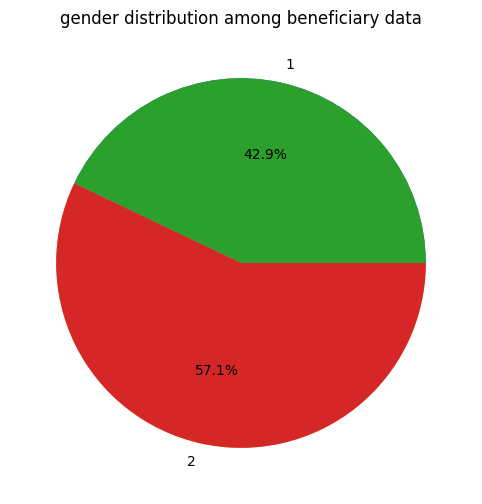

In [ ]:
def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%".format(pct, absolute)

plt.figure(figsize=(8,6),dpi=100)

data=bene_train.groupby('Gender').count().BeneID
fig = plt.pie(data,
              labels=data.index,
              autopct = lambda pct: func(pct, data.values),)
plt.title("gender distribution among beneficiary data")

fig = plt.pie(data)

# Adding new feature and dropping features that are irrelevent

In [ ]:
bene_train['RenalDiseaseIndicator'][:10]

,RenalDiseaseIndicator
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,Y
9,0


In [ ]:
# this value indicates whether the beneficiary has renal disease
bene_train['RenalDiseaseIndicator'].replace('Y','1',inplace=True)
bene_train['RenalDiseaseIndicator'] = bene_train['RenalDiseaseIndicator'].astype(int)


bene_test['RenalDiseaseIndicator'].replace('Y','1',inplace=True)
bene_test['RenalDiseaseIndicator'] = bene_test['RenalDiseaseIndicator'].astype(int)


<ipython-input-20-4fb0b7fe072b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bene_train['RenalDiseaseIndicator'].replace('Y','1',inplace=True)
<ipython-input-20-4fb0b7fe072b>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

# Data Reduction: Delete DOD DOB and change it into new feature 'Age' and 'Alive'

In [ ]:
for col in ['DOB','DOD']:
    bene_train[col] = pd.to_datetime(bene_train[col])
    bene_test[col] = pd.to_datetime(bene_test[col])


bene_train['BirthYear'] = bene_train['DOB'].dt.year
bene_test['BirthYear'] = bene_test['DOB'].dt.year


# Greatest Date of Death in the TRAIN set for beneficiaries
max_bene_DOD = max(bene_train['DOD'].unique()[1:])
# For all NAN DODs filling the greatest Date of Death
bene_train['DOD'].fillna(value=max_bene_DOD, inplace=True)

# Same thing for the test set
max_bene_DOD = max(bene_test['DOD'].unique()[1:])
# For all NAN DODs filling the greatest Date of Death
bene_test['DOD'].fillna(value=max_bene_DOD, inplace=True)


bene_train['Age'] = round(((bene_train['DOD'] - bene_train['DOB']).dt.days)/365,0)
bene_test['Age'] = round(((bene_test['DOD'] - bene_test['DOB']).dt.days)/365,0)

<ipython-input-21-e7151c4a0b39>:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bene_train['DOD'].fillna(value=max_bene_DOD, inplace=True)
<ipython-input-21-e7151c4a0b39>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
bene_train['Alive'] = bene_train['DOD'].apply(lambda x: 1 if x != x else 0)
bene_test['Alive'] = bene_test['DOD'].apply(lambda x: 1 if x != x else 0)

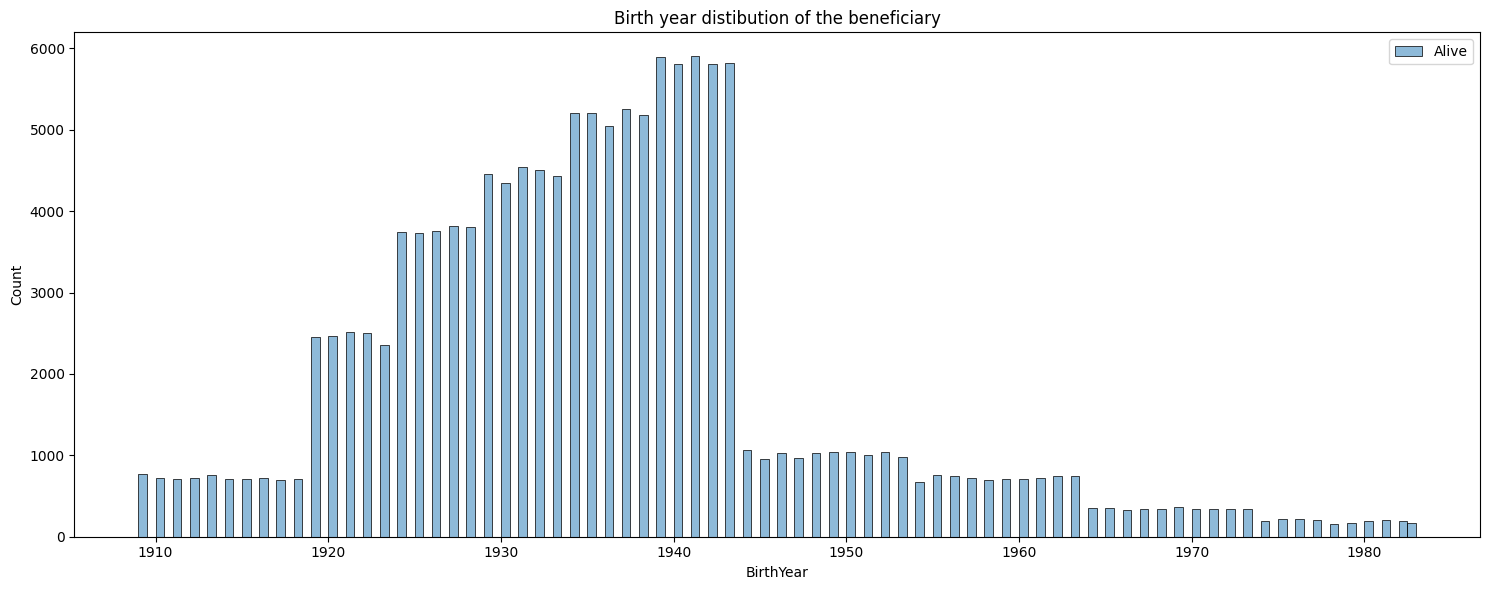

In [ ]:
fig, ax = plt.subplots(figsize=(15,6),dpi=100)

sns.histplot(data=bene_train,x='BirthYear',hue='Alive',legend=False,ax=ax)
plt.legend(['Alive','Dead'])
plt.title('Birth year distibution of the beneficiary')
#fig = plt.bar(x=bene_train['BirthYear'].value_counts().index, height = bene_train['BirthYear'].value_counts())
plt.tight_layout()
plt.show()

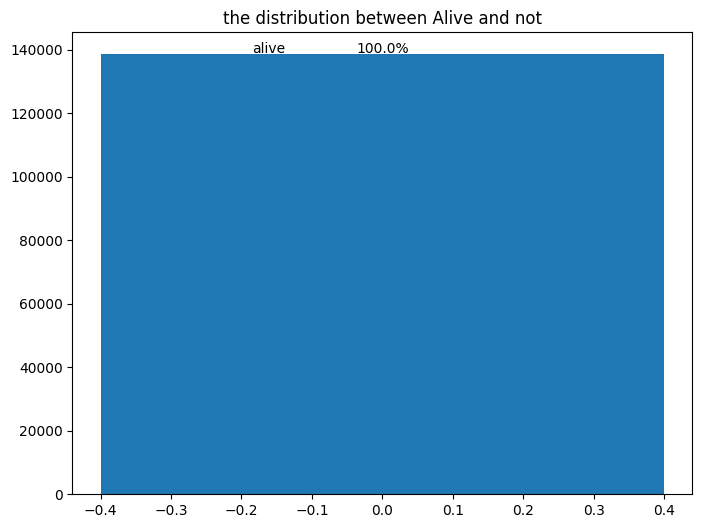

In [ ]:
plt.figure(figsize=(8,6))

fig = plt.bar(x=bene_train['Alive'].value_counts().index, height = bene_train['Alive'].value_counts())
plt.title('the distribution between Alive and not')
label = ['alive','dead']
# plt.xticks()
cnt = 0
for p in fig.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    plt.annotate(label[cnt],(x+width/3.35,y+height+280),ha='center')
    plt.annotate(f'{str(round((100*height)/(bene_train["Alive"].shape[0]),2))+"%"}',(x+width/2,y+height+280),ha='center')
    cnt+=1

plt.show()

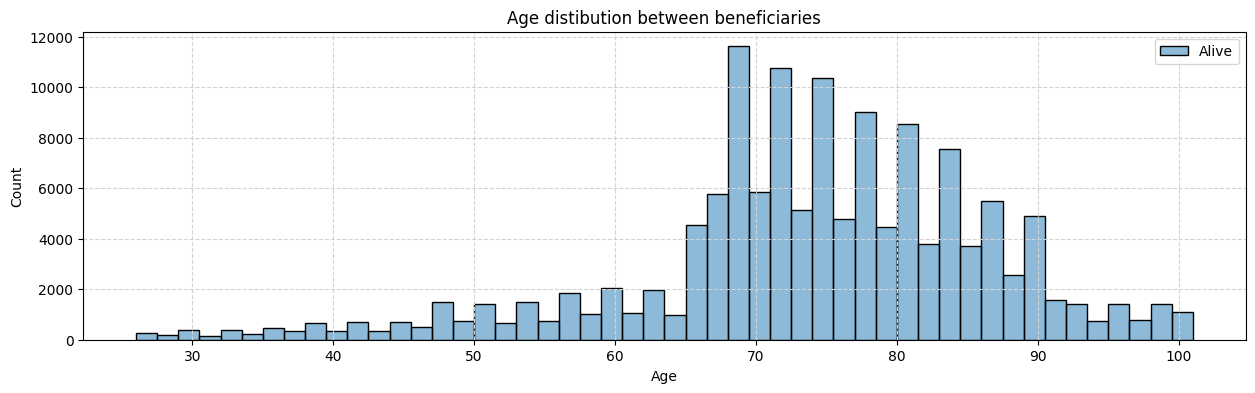

In [ ]:
fig, ax = plt.subplots(figsize=(15,4),dpi=100)
ax.grid( linestyle="--", color='lightgrey')
plt.title('Age distibution between beneficiaries')

sns.histplot(data=bene_train,x='Age',hue='Alive',legend=False,ax=ax,bins=50) #bins=5
plt.legend(['Alive','Dead'])
#fig = plt.bar(x=bene_train['BirthYear'].value_counts().index, height = bene_train['BirthYear'].value_counts())

plt.show()

In [ ]:
bene_train.drop(labels=['DOD','BirthYear'],axis=1,inplace=True)
bene_test.drop(labels=['DOD','BirthYear'],axis=1,inplace=True)

# NoOfMonths_PartACOV and NoOfMonths_PartBCOV

In [ ]:
bene_train.groupby('NoOfMonths_PartACov').count()

,BeneID,DOB,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,Alive
NoOfMonths_PartACov,,,,,,,,,,,,,,,,,,,,,
0,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
1,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,5,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
3,5,5,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
4,13,13,13,13,13,13,13,13,13,13,...,13,13,13,13,13,13,13,13,13,13
5,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
6,38,38,38,38,38,38,38,38,38,38,...,38,38,38,38,38,38,38,38,38,38
7,16,16,16,16,16,16,16,16,16,16,...,16,16,16,16,16,16,16,16,16,16
8,26,26,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26


In [ ]:
bene_train.groupby('NoOfMonths_PartBCov').count()

,BeneID,DOB,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,Alive
NoOfMonths_PartBCov,,,,,,,,,,,,,,,,,,,,,
0,675,675,675,675,675,675,675,675,675,675,...,675,675,675,675,675,675,675,675,675,675
1,17,17,17,17,17,17,17,17,17,17,...,17,17,17,17,17,17,17,17,17,17
2,19,19,19,19,19,19,19,19,19,19,...,19,19,19,19,19,19,19,19,19,19
3,27,27,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
4,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
5,50,50,50,50,50,50,50,50,50,50,...,50,50,50,50,50,50,50,50,50,50
6,282,282,282,282,282,282,282,282,282,282,...,282,282,282,282,282,282,282,282,282,282
7,63,63,63,63,63,63,63,63,63,63,...,63,63,63,63,63,63,63,63,63,63
8,71,71,71,71,71,71,71,71,71,71,...,71,71,71,71,71,71,71,71,71,71


In [ ]:
diseases = ['ChronicCond_Alzheimer','ChronicCond_Heartfailure',
           'ChronicCond_KidneyDisease','ChronicCond_Cancer','ChronicCond_ObstrPulmonary',
          'ChronicCond_Depression','ChronicCond_Diabetes','ChronicCond_IschemicHeart','ChronicCond_Osteoporasis',
           'ChronicCond_rheumatoidarthritis','ChronicCond_stroke']

In [ ]:
df_train = bene_train.copy()
df_test = bene_test.copy()

In [ ]:
df_train.shape

(138556, 26)

In [ ]:
df_test.shape

(63968, 26)

In [ ]:
for df in [df_train, df_test]:
    for i in range(df.shape[0]):#
        chronicDCnt = 0
        for disease in diseases:
            if df_train.loc[i,disease] > 1:
                 chronicDCnt+=1
            else:
                 continue
        df.loc[i,'ChronicDiseaseIndex'] = chronicDCnt

In [ ]:
df_train.drop(diseases,inplace=True,axis=1)
df_test.drop(diseases,inplace=True,axis=1)

In [ ]:
df_train

,BeneID,DOB,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,Alive,ChronicDiseaseIndex
0,BENE11001,1943-01-01,1,1,0,39,230,12,12,36000,3204,60,70,67.0,0,4.0
1,BENE11002,1936-09-01,2,1,0,39,280,12,12,0,0,30,50,73.0,0,11.0
2,BENE11003,1936-08-01,1,1,0,52,590,12,12,0,0,90,40,73.0,0,9.0
3,BENE11004,1922-07-01,1,1,0,39,270,12,12,0,0,1810,760,87.0,0,5.0
4,BENE11005,1935-09-01,1,1,0,24,680,12,12,0,0,1790,1200,74.0,0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138551,BENE159194,1939-07-01,1,1,0,39,140,12,12,0,0,430,460,70.0,0,10.0
138552,BENE159195,1938-12-01,2,1,0,49,530,12,12,0,0,880,100,71.0,0,9.0
138553,BENE159196,1916-06-01,2,1,0,6,150,12,12,2000,1068,3240,1390,94.0,0,5.0
138554,BENE159197,1930-01-01,1,1,0,16,560,12,12,0,0,2650,10,80.0,0,8.0


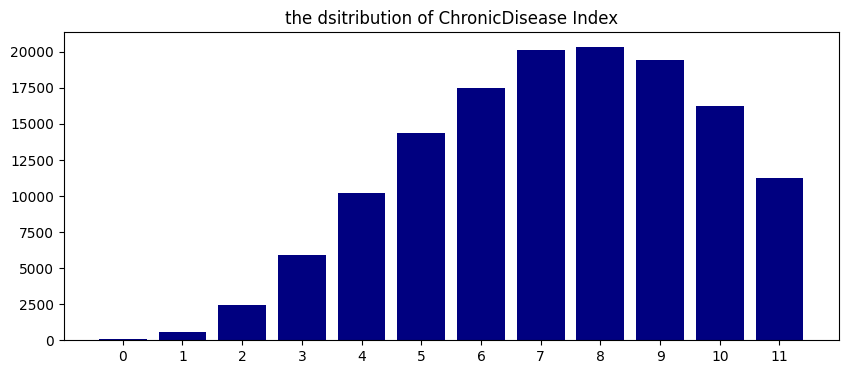

In [ ]:
fig, ax = plt.subplots(figsize=(10,4),dpi=100)
data = df_train.groupby('ChronicDiseaseIndex').count().BeneID
plt.title('the dsitribution of ChronicDisease Index')
plt.bar(x=data.index,height=data,color='navy')
plt.xticks(np.arange(0,12,1))
plt.show()

In [ ]:
bene_train = df_train.copy()
bene_test = df_train.copy()

In [ ]:
#labelencoder = LabelEncoder()

for df in [bene_train,bene_test]:
    for col in ['Race','State','County']:
        df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
#bene_train.drop(diseases,axis=1,inplace=True)
bene_train.columns

Index(['BeneID', 'DOB', 'Gender', 'Race', 'RenalDiseaseIndicator', 'State',
       'County', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
       'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age', 'Alive',
       'ChronicDiseaseIndex'],
      dtype='object')

# Inpatient data and Outpatient data

In [ ]:
inp_train.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,4/12/2009,4/18/2009,PRV55912,26000,PHY390922,NaN,NaN,4/12/2009,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,8/31/2009,9/2/2009,PRV55907,5000,PHY318495,PHY318495,NaN,8/31/2009,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,9/17/2009,9/20/2009,PRV56046,5000,PHY372395,NaN,PHY324689,9/17/2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2/14/2009,2/22/2009,PRV52405,5000,PHY369659,PHY392961,PHY349768,2/14/2009,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,8/13/2009,8/30/2009,PRV56614,10000,PHY379376,PHY398258,NaN,8/13/2009,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


Claim Start date & Claim End Date

In [ ]:
for df in [inp_train,inp_test,outp_test,outp_train]:
        for col in ['ClaimStartDt','ClaimEndDt']:
            df[col] = pd.to_datetime(df[col])

        df['ClaimPeriod'] =  round(((df.ClaimEndDt - df.ClaimStartDt).dt.days),0)



for df in [inp_train,inp_test]:
            df.AdmissionDt = pd.to_datetime(df.AdmissionDt)
            df.DischargeDt = pd.to_datetime(df.DischargeDt)
            df['TimeInHptal'] =  round(((df.DischargeDt - df.AdmissionDt).dt.days),0)
            df.drop(['DischargeDt','AdmissionDt'],axis=1,inplace=True)
#             delta = df.DischargeDt - df.AdmissionDt
#             delta_as_time_obj = time.gmtime(delta.total_seconds())
#             df['TimeInHptal'] = time.strftime('%d', delta_as_time_obj)

Creating a new DischargeDt and AdmissionDt

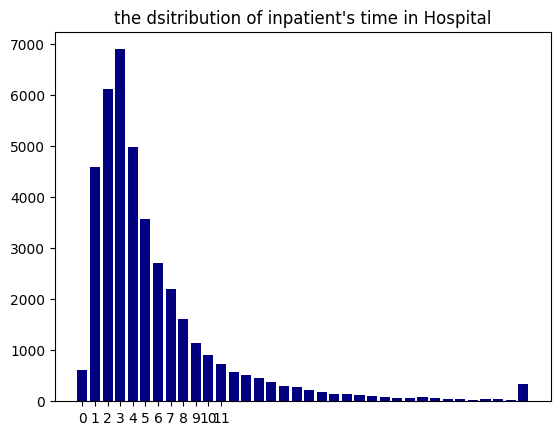

In [ ]:
data = inp_train.groupby('TimeInHptal').count().BeneID
plt.title("the distribution of inpatient's time in Hospital")
plt.bar(x=data.index,height=data,color='navy')
plt.xticks(np.arange(0,12,1))
plt.show()

In [ ]:
ClmProcedureCode = ['ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
        'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',]

In [ ]:
ClmDiagnosisCode = ['ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4',
       'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
       'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10']

In [ ]:
for code in ClmDiagnosisCode:
    inp_train.fillna('-1',inplace=True)
    outp_train.fillna('-1',inplace=True)

<ipython-input-45-48145c699506>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inp_train.fillna('-1',inplace=True)
<ipython-input-45-48145c699506>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  outp_train.fillna('-1',inplace=True)


In [ ]:
def CountingIndex(df,codeList,indexName):

    for i in range(df.shape[0]):#
        DiagnosisCnt = 0
        for code in codeList:
            if df.loc[i,code]== '-1':

                continue

            else:
                 DiagnosisCnt+=1
        df.loc[i,indexName] = DiagnosisCnt

In [ ]:
CountingIndex(inp_train,ClmDiagnosisCode,'DiagnosisIndex')

In [ ]:
CountingIndex(outp_train,ClmDiagnosisCode,'DiagnosisIndex')

In [ ]:
CountingIndex(inp_train,ClmProcedureCode,'ProcedureIndex')

In [ ]:
CountingIndex(outp_train,ClmProcedureCode,'ProcedureIndex')

In [ ]:
ClmDiagnosisCode.remove('ClmDiagnosisCode_1')
inp_train.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,...,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,ClaimPeriod,TimeInHptal,DiagnosisIndex,ProcedureIndex
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,-1,-1,7866,...,-1,-1,-1,-1,-1,-1,6,6,9.0,0.0
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,-1,6186,...,7092.0,-1,-1,-1,-1,-1,2,2,3.0,1.0
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,-1,PHY324689,29590,...,-1,-1,-1,-1,-1,-1,3,3,6.0,0.0
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,431,...,331.0,-1,-1,-1,-1,-1,8,8,9.0,1.0
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,-1,78321,...,3893.0,-1,-1,-1,-1,-1,17,17,9.0,1.0


In [ ]:
CountingIndex(inp_test,ClmProcedureCode,'ProcedureIndex')
CountingIndex(inp_test,ClmDiagnosisCode,'DiagnosisIndex')

CountingIndex(outp_test,ClmProcedureCode,'ProcedureIndex')
CountingIndex(outp_test,ClmDiagnosisCode,'DiagnosisIndex')

In [ ]:
inp_train.groupby('DiagnosisIndex').count()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,...,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,ClaimPeriod,TimeInHptal,ProcedureIndex
DiagnosisIndex,,,,,,,,,,,,,,,,,,,,,
1.0,226,226,226,226,226,226,226,226,226,226,...,226,226,226,226,226,226,226,226,226,226
2.0,450,450,450,450,450,450,450,450,450,450,...,450,450,450,450,450,450,450,450,450,450
3.0,858,858,858,858,858,858,858,858,858,858,...,858,858,858,858,858,858,858,858,858,858
4.0,1359,1359,1359,1359,1359,1359,1359,1359,1359,1359,...,1359,1359,1359,1359,1359,1359,1359,1359,1359,1359
5.0,1944,1944,1944,1944,1944,1944,1944,1944,1944,1944,...,1944,1944,1944,1944,1944,1944,1944,1944,1944,1944
6.0,2420,2420,2420,2420,2420,2420,2420,2420,2420,2420,...,2420,2420,2420,2420,2420,2420,2420,2420,2420,2420
7.0,2684,2684,2684,2684,2684,2684,2684,2684,2684,2684,...,2684,2684,2684,2684,2684,2684,2684,2684,2684,2684
8.0,3555,3555,3555,3555,3555,3555,3555,3555,3555,3555,...,3555,3555,3555,3555,3555,3555,3555,3555,3555,3555
9.0,23050,23050,23050,23050,23050,23050,23050,23050,23050,23050,...,23050,23050,23050,23050,23050,23050,23050,23050,23050,23050


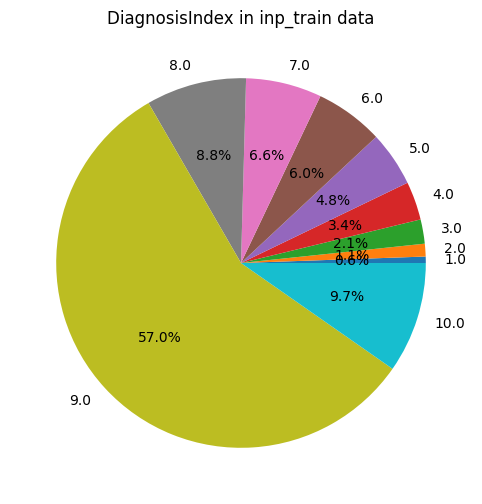

In [ ]:
plt.figure(figsize=(8,6),dpi=100)

data = inp_train.groupby('DiagnosisIndex').count().BeneID

fig = plt.pie(data,
              labels=data.index,
              autopct = lambda pct: func(pct, data.values),)
plt.title('DiagnosisIndex in inp_train data')


plt.show()

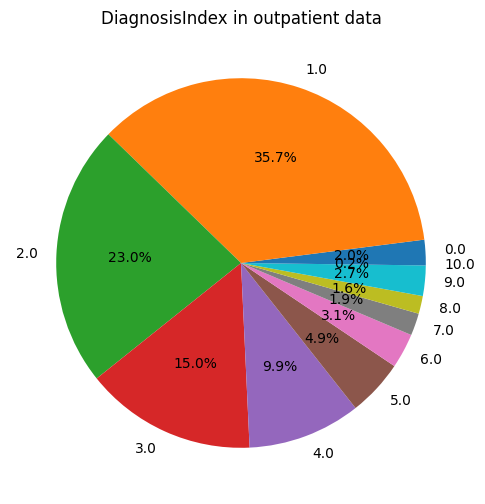

In [ ]:
plt.figure(figsize=(8,6),dpi=100)
data = outp_train.groupby('DiagnosisIndex').count().BeneID



fig = plt.pie(data,
              labels=data.index,
              autopct = lambda pct: func(pct, data.values),)
plt.title('DiagnosisIndex in outpatient data')


plt.show()

In [ ]:
inp_train.columns

Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid',
       'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
       'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
       'ClmProcedureCode_5', 'ClmProcedureCode_6', 'ClaimPeriod',
       'TimeInHptal', 'DiagnosisIndex', 'ProcedureIndex'],
      dtype='object')

In [ ]:
def isSamePhysician(df):
    for i in range(0,df.shape[0]):

        if  df.loc[i,['AttendingPhysician']][0] == df.loc[i,['OperatingPhysician']][0]:
            df.loc[i,'SamePhysician'] = 1
        else:
            df.loc[i,'SamePhysician'] = 0

In [ ]:
inp_train.OtherPhysician.fillna(0,inplace=True)
outp_train.OtherPhysician.fillna(0,inplace=True)

<ipython-input-58-6c335b381c75>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inp_train.OtherPhysician.fillna(0,inplace=True)
<ipython-input-58-6c335b381c75>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
inp_test.OtherPhysician.fillna(0,inplace=True)
outp_test.OtherPhysician.fillna(0,inplace=True)

<ipython-input-59-e9f3c0116b1b>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inp_test.OtherPhysician.fillna(0,inplace=True)
<ipython-input-59-e9f3c0116b1b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:
for df in [inp_train,outp_train,inp_test,outp_train]:
    for col in ['AttendingPhysician','OperatingPhysician']:
        df[col].dropna(inplace=True)

In [ ]:
isSamePhysician(inp_train)
isSamePhysician(outp_train)

Streaming output truncated to the last 5000 lines.
<ipython-input-57-6202da0f80ea>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if  df.loc[i,['AttendingPhysician']][0] == df.loc[i,['OperatingPhysician']][0]:
<ipython-input-57-6202da0f80ea>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if  df.loc[i,['AttendingPhysician']][0] == df.loc[i,['OperatingPhysician']][0]:
<ipython-input-57-6202da0f80ea>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use 

In [ ]:
bene_train.to_csv('bene_train.csv' ,sep='\t', encoding='utf-8')

# Provider and the frauds

In [ ]:
label_train

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No
...,...,...
5405,PRV57759,No
5406,PRV57760,No
5407,PRV57761,No
5408,PRV57762,No


In [ ]:
prov_num = len(label_train['Provider'].unique())
prov_num

5410

In [ ]:
label_test

,Provider
0,PRV51002
1,PRV51006
2,PRV51009
3,PRV51010
4,PRV51018
...,...
1348,PRV57713
1349,PRV57726
1350,PRV57745
1351,PRV57749


In [ ]:
label_train['PotentialFraud'].replace('No',0,inplace=True)
label_train['PotentialFraud'].replace('Yes',1,inplace=True)

#label_test['PotentialFraud'].replace('No',0,inplace=True)
#label_test['PotentialFraud'].replace('Yes',1,inplace=True)


fraud = label_train[label_train['PotentialFraud']==1]
fraud.shape[0]

<ipython-input-67-7222b637b2a1>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  label_train['PotentialFraud'].replace('No',0,inplace=True)
<ipython-input-67-7222b637b2a1>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)'

506

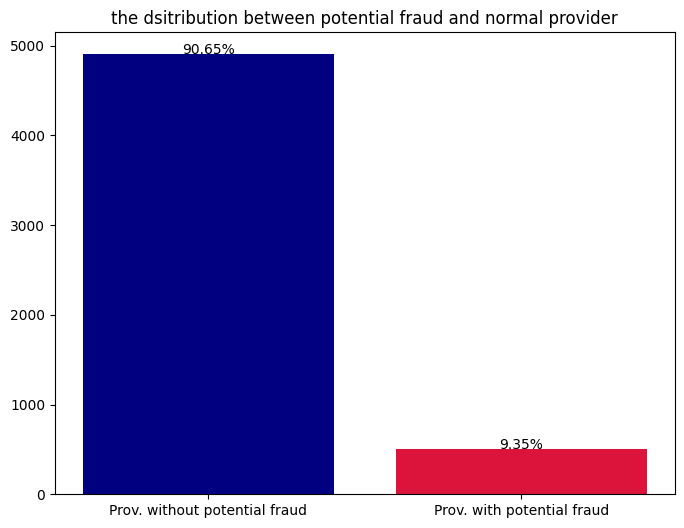

In [ ]:
label_train.groupby('PotentialFraud').count()
plt.figure(figsize=(8,6),dpi=100)
data=label_train.groupby('PotentialFraud').count()
labels=['Prov. without potential fraud','Prov. with potential fraud']
fig = plt.bar(x=data.index, height = data.Provider,color=['navy','crimson'])
plt.title('the dsitribution between potential fraud and normal provider')
x_pos = np.arange(2)
plt.xticks(x_pos, labels=labels)

cnt = 0
for p in fig.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    #plt.annotate(label[cnt],(x+width/2,y+height),ha='center')
    plt.annotate(f'{str(round((100*height)/(label_train.shape[0]),2))+"%"}',(x+width/2,y+height),ha='center')
    cnt+=1

plt.show()

# Merging the dataset

In [ ]:
for df in [inp_train,inp_test,outp_test,outp_train]:
    try:
        df.drop(['ClaimStartDt','ClaimEndDt'],axis=1,inplace=True)
    except:
        continue

In [ ]:
delete = ClmProcedureCode+ClmDiagnosisCode
for df in [inp_train,inp_test,outp_test,outp_train]:
    try:
        df.drop(delete,axis=1,inplace=True)
    except:
        continue

In [ ]:
common_cols = [col for col in outp_train.columns if col in inp_train.columns]

In [ ]:
common_cols

['BeneID',
 'ClaimID',
 'Provider',
 'InscClaimAmtReimbursed',
 'AttendingPhysician',
 'OperatingPhysician',
 'OtherPhysician',
 'ClmDiagnosisCode_1',
 'DeductibleAmtPaid',
 'ClmAdmitDiagnosisCode',
 'ClaimPeriod',
 'DiagnosisIndex',
 'ProcedureIndex',
 'SamePhysician']

In [ ]:
inp_train["Admitted"] = 1
outp_train["Admitted"] = 0
inp_test["Admitted"] = 1
outp_test["Admitted"] = 0

In [ ]:
inp_train.DeductibleAmtPaid = inp_train.DeductibleAmtPaid.astype(int)
inp_test.DeductibleAmtPaid = inp_test.DeductibleAmtPaid.fillna(-9999).astype(int)

In [ ]:
ip_op_train = pd.merge(left=inp_train, right=outp_train, how='outer')
ip_op_test = pd.merge(left=inp_test, right=outp_test, how='outer')

In [ ]:
ip_op_train = pd.merge(left=ip_op_train, right=label_train, on='Provider', how='inner')
ip_op_test = pd.merge(left=ip_op_test, right=label_test, on='Provider', how='inner')

In [ ]:
# Joining the IP_OP dataset with the BENE data
train_df = pd.merge(left=ip_op_train, right=bene_train, left_on='BeneID', right_on='BeneID',how='inner')
train_df.shape

(558209, 33)

In [ ]:
test_df = pd.merge(left=ip_op_test, right=bene_test, left_on='BeneID', right_on='BeneID',how='inner')
test_df.shape

(115530, 31)

In [ ]:
outp_test.shape[0] +inp_test.BeneID.shape[0]
test_df.to_csv('test.csv' ,sep='\t', encoding='utf-8')
train_df.to_csv('train.csv' ,sep='\t', encoding='utf-8')

# Some EDA for the train set

# Machine Learning

In [ ]:
train_1 = train_df.copy()

In [ ]:
train_1.columns

Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician',
       'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClaimPeriod', 'TimeInHptal', 'DiagnosisIndex',
       'ProcedureIndex', 'SamePhysician', 'Admitted', 'PotentialFraud', 'DOB',
       'Gender', 'Race', 'RenalDiseaseIndicator', 'State', 'County',
       'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
       'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
       'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'Age', 'Alive',
       'ChronicDiseaseIndex'],
      dtype='object')

In [ ]:
obj_list = ['BeneID', 'ClaimID','Provider','AttendingPhysician', 'ClmAdmitDiagnosisCode','OperatingPhysician', 'OtherPhysician','DiagnosisGroupCode','ClmDiagnosisCode_1','SamePhysician']

In [ ]:
labelencoder = LabelEncoder()
for col in obj_list:
    train_1[col] = labelencoder.fit_transform(train_1[col])

In [ ]:
X = train_1.drop(['PotentialFraud','DOB'],axis=1)
y = train_1['PotentialFraud']

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558209 entries, 0 to 558208
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   BeneID                    558209 non-null  int64  
 1   ClaimID                   558209 non-null  int64  
 2   Provider                  558209 non-null  int64  
 3   InscClaimAmtReimbursed    558209 non-null  int64  
 4   AttendingPhysician        558209 non-null  int64  
 5   OperatingPhysician        558209 non-null  int64  
 6   OtherPhysician            558209 non-null  int64  
 7   ClmAdmitDiagnosisCode     558209 non-null  int64  
 8   DeductibleAmtPaid         558209 non-null  int64  
 9   DiagnosisGroupCode        558209 non-null  int64  
 10  ClmDiagnosisCode_1        558209 non-null  int64  
 11  ClaimPeriod               558209 non-null  int64  
 12  TimeInHptal               40473 non-null   float64
 13  DiagnosisIndex            558209 non-null  f

In [ ]:
X = X.fillna(-9999)

In [ ]:
X_train, X_val, y_train, y_val = tts(X, y, test_size=0.20, stratify=y, random_state=42)
# Checking shape of each set
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((446567, 31), (111642, 31), (446567,), (111642,))

In [ ]:
# Checking count of target labels in y_train
y_train.value_counts()

,count
PotentialFraud,
0,276331
1,170236


In [ ]:
X_val.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DiagnosisGroupCode,...,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,Alive,ChronicDiseaseIndex
306000,75688,315628,4072,800,75757,0,42999,0,0,736,...,36,12,12,0,0,3020,620,95.0,0,6.0
312894,77417,189480,5196,300,67466,0,0,0,0,736,...,103,12,12,0,0,300,100,81.0,0,9.0
124801,30771,441286,4861,0,78536,33819,44542,0,0,736,...,5,12,12,10000,2136,3970,530,79.0,0,7.0
276915,68445,224218,805,60,23836,0,13517,0,0,736,...,29,12,12,4080,1068,2710,580,84.0,0,6.0
234841,58069,163040,4138,0,8452,24579,0,0,0,736,...,154,12,12,13000,1068,390,310,87.0,0,5.0


# Random Forest

In [ ]:
#random forest model creation
rfc = RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=123,max_depth=4)
rfc.fit(X_train, y_train)
#predictions

RandomForestClassifier(class_weight='balanced', max_depth=4, n_estimators=500,
                       random_state=123)

In [ ]:
y_predict = rfc.predict(X_val)

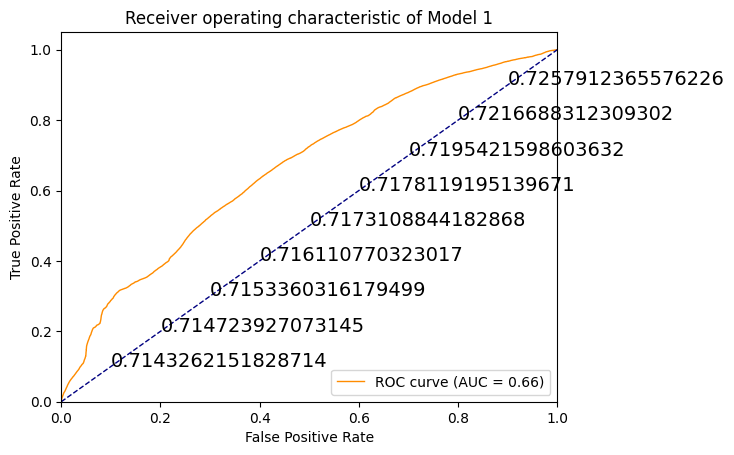

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val, rfc.predict_proba(X_val)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (AUC = %0.2f)' % roc_auc)

for label in range(1,10,1):
    plt.text((10-label)/10,(10-label)/10,thresholds[label*15],fontdict={'size': 14})

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic of Model 1')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#building all kinds of evaluating parameters
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix

n_outliers = len(fraud)
n_errors = (y_predict != y_val).sum()
print("The model used is Random Forest classifier")

acc = accuracy_score(y_val, y_predict)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict)
print("The F1-Score is {}".format(f1))

MCC = matthews_corrcoef(y_val, y_val)
print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier
The accuracy is 0.6470414360187027
The precision is 0.5584290477954799
The recall is 0.3541436593904932
The F1-Score is 0.43342104128024844
The Matthews correlation coefficient is1.0


In [ ]:
#random forest model creation
rfc2 = RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=123,max_depth=10)
rfc2.fit(X_train, y_train)
#predictions

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=500,
                       random_state=123)

In [ ]:
y_predict2 = rfc2.predict(X_val)

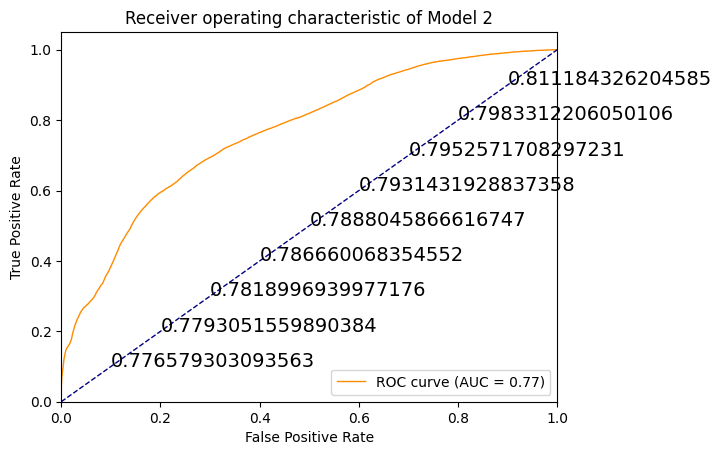

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, rfc2.predict_proba(X_val)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (AUC = %0.2f)' % roc_auc)

for label in range(1,10,1):
    plt.text((10-label)/10,(10-label)/10,thresholds[label*15],fontdict={'size': 14})

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic of Model 2')
plt.legend(loc="lower right")
plt.show()

In [ ]:
print("The model used is Random Forest classifier with depth of 10")

acc = accuracy_score(y_val, y_predict2)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict2)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict2)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict2)
print("The F1-Score is {}".format(f1))

# MCC = matthews_corrcoef(y_val, y_test)
# print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier with depth of 10
The accuracy is 0.7253632145608283
The precision is 0.6628435344355633
The recall is 0.5689748349350313
The F1-Score is 0.6123326295027247


In [ ]:
#random forest model creation
rfc3 = RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=123,max_depth=15)
rfc3.fit(X_train, y_train)
#predictions
y_predict3 = rfc3.predict(X_val)

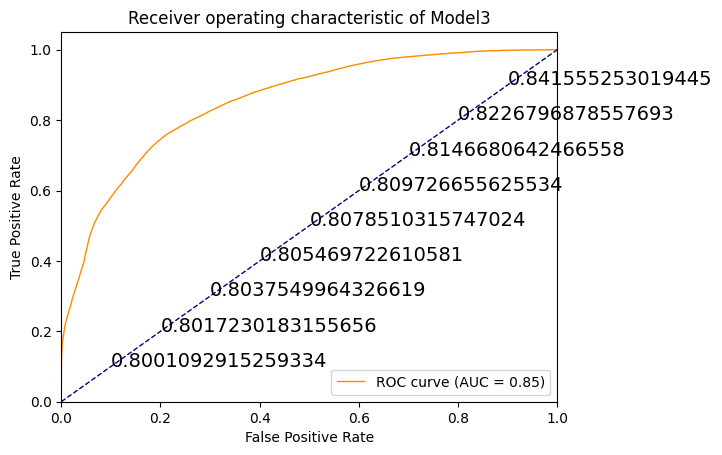

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, rfc3.predict_proba(X_val)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (AUC = %0.2f)' % roc_auc)

for label in range(1,10,1):
    plt.text((10-label)/10,(10-label)/10,thresholds[label*15],fontdict={'size': 14})

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic of Model3')
plt.legend(loc="lower right")
plt.show()

In [ ]:
print("The model used is Random Forest classifier with depth of 15")

acc = accuracy_score(y_val, y_predict3)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict3)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict3)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict3)
print("The F1-Score is {}".format(f1))

# MCC = matthews_corrcoef(y_val, y_test)
# print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier with depth of 15
The accuracy is 0.7812919868866556
The precision is 0.735402501686822
The recall is 0.665852111186823
The F1-Score is 0.6989012615145573


In [ ]:
#random forest model creation
rfc4 = RandomForestClassifier(n_estimators=500,class_weight='balanced',random_state=123,max_depth=25)
rfc4.fit(X_train, y_train)
#predictions
y_predict4 = rfc4.predict(X_val)

In [ ]:
print("The model used is Random Forest classifier with depth of 25")

acc = accuracy_score(y_val, y_predict4)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict4)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict4)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict4)
print("The F1-Score is {}".format(f1))

# MCC = matthews_corrcoef(y_val, y_test)
# print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier with depth of 25
The accuracy is 0.8679797925511904
The precision is 0.8636411168043501
The recall is 0.7762400432340986
The F1-Score is 0.8176114637858707


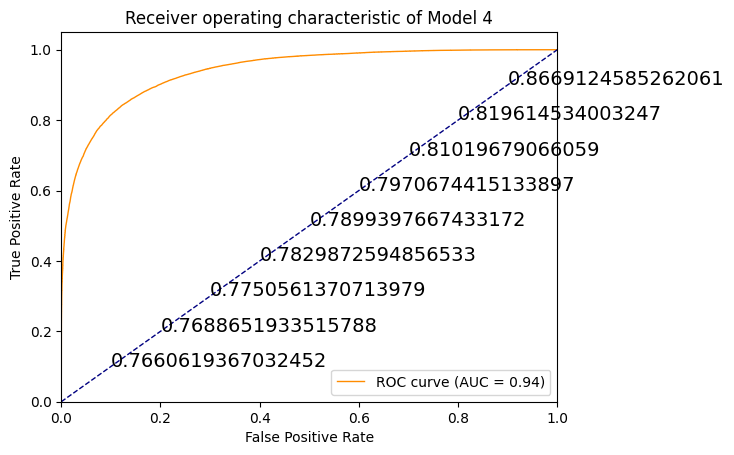

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, rfc4.predict_proba(X_val)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (AUC = %0.2f)' % roc_auc)

for label in range(1,10,1):
    plt.text((10-label)/10,(10-label)/10,thresholds[label*15],fontdict={'size': 14})

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic of Model 4')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#random forest model creation
rfc5 = RandomForestClassifier(n_estimators=1000,class_weight='balanced',random_state=123,max_depth=25)
rfc5.fit(X_train, y_train)
#predictions
y_predict5 = rfc5.predict(X_val)

In [ ]:
print("The model used is Random Forest classifier with depth of 25 and estimators of 1000")

acc = accuracy_score(y_val, y_predict5)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict5)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict5)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict5)
print("The F1-Score is {}".format(f1))

# MCC = matthews_corrcoef(y_val, y_test)
# print("The Matthews correlation coefficient is{}".format(MCC))

The model used is Random Forest classifier with depth of 25 and estimators of 1000
The accuracy is 0.8688128123824367
The precision is 0.8652099960748397
The recall is 0.7768979534293569
The F1-Score is 0.8186792779854903


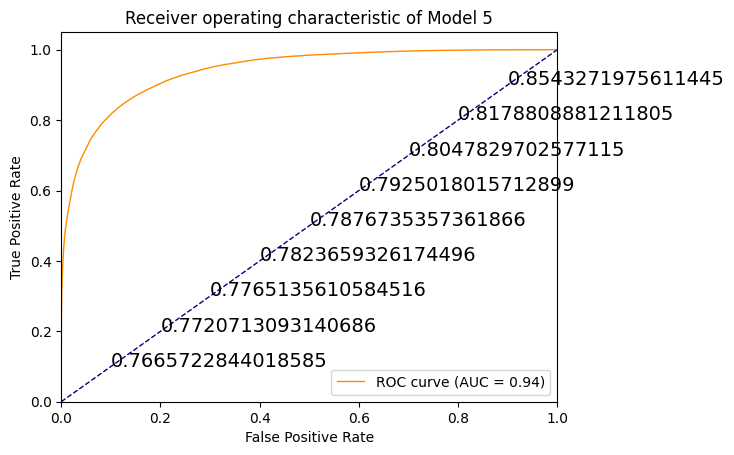

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, rfc5.predict_proba(X_val)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (AUC = %0.2f)' % roc_auc)

for label in range(1,10,1):
    plt.text((10-label)/10,(10-label)/10,thresholds[label*15],fontdict={'size': 14})

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic of Model 5')
plt.legend(loc="lower right")
plt.show()

In [ ]:
cnt=0
for model in [rfc,rfc2,rfc4,rfc4,rfc5]:
    cnt+=1
    print("model",cnt)
    #print("used estimators:",model.estimators_[-1])
    print("feature_importances_",model.feature_importances_)
    print("num of feature seen during fitting :",model.n_features_in_,"\n")

model 1
feature_importances_ [4.05418361e-04 7.52303843e-04 2.84351047e-01 3.36948893e-02
 4.52092879e-02 6.01294455e-03 1.09326475e-02 3.43127306e-03
 6.02326057e-02 9.13861813e-02 2.03273868e-04 9.07017040e-03
 7.41408322e-02 1.13110097e-02 2.28613403e-02 3.69617318e-03
 7.25553292e-02 1.83593194e-05 8.87331735e-03 1.38582087e-05
 1.39422718e-01 1.15271400e-01 5.16709805e-05 2.52533300e-05
 1.43846513e-03 2.45244679e-03 8.36441947e-04 6.59399469e-04
 5.78662196e-04 0.00000000e+00 1.11280783e-04]
num of feature seen during fitting : 31 

model 2
feature_importances_ [5.25570245e-03 4.28261560e-03 3.97503631e-01 1.25216369e-02
 7.72592497e-02 1.28442859e-02 2.71779130e-02 3.57503593e-03
 2.08570120e-02 2.67316520e-02 3.58647641e-03 4.09244751e-03
 2.55259557e-02 4.62278049e-03 6.66048099e-03 3.78085354e-03
 2.16572387e-02 5.33613414e-04 5.40468705e-03 4.24089664e-04
 1.79357996e-01 1.32942883e-01 2.19723254e-04 2.49214102e-04
 3.73398843e-03 2.13060679e-03 5.30712341e-03 4.95089902e-03

# Support Vector Machine(SVM)

In [ ]:
from sklearn import svm

In [ ]:
from cuml.svm import SVC

svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)

SVC()

In [ ]:
svm_model = svm.SVC()
svm_model.fit(X_train, y_train)

In [ ]:
#predictions
y_predict_svm = svm_model.predict(X_val)

In [ ]:
print("The model used is SVM (Support Vector Machines)")

acc = accuracy_score(y_val, y_predict_svm)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict_svm)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict_svm)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict_svm)
print("The F1-Score is {}".format(f1))

The model used is SVM (Support Vector Machines)
The accuracy is 0.6297809068271797
The precision is 0.577374195989406
The recall is 0.10756831692473977
The F1-Score is 0.1813500237680241


# KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors = 3)
knn_model.fit(X_train, y_train)

In [ ]:
from cuml.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
#predictions
y_predict_knn = knn_model.predict(X_val)

In [ ]:
print("The model used is KNN (Support Vector Machines)")

acc = accuracy_score(y_val, y_predict_knn)
print("The accuracy is {}".format(acc))

prec = precision_score(y_val, y_predict_knn)
print("The precision is {}".format(prec))

rec = recall_score(y_val,y_predict_knn)
print("The recall is {}".format(rec))

f1 = f1_score(y_val, y_predict_knn)
print("The F1-Score is {}".format(f1))

The model used is KNN (Support Vector Machines)
The accuracy is 0.5640171261711542
The precision is 0.41293886500185084
The recall is 0.3407504875584483
The F1-Score is 0.3733875743453745
